# ST-GNN Model Results

Visualizza i risultati del modello salvato da `python main.py`.

> **Pre-requisito**: eseguire `python main.py` dalla root del progetto.

In [ ]:
import sys, json, os
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import xarray as xr

from main import _normalize_dataset
from physiq_pv.model.st_gnn import STGNN
from physiq_pv.model.graph_builder import build_graph
from physiq_pv.data.dataset import PVDataset
from physiq_pv.data.quality_score import compute_qs
from physiq_pv.data.load_kwp import load_kwp
from physiq_pv.data.sentinel_hourly_loader import load_sentinel_hourly, merge_with_weather
from torch.utils.data import DataLoader

sns.set_theme(style='darkgrid')
CKPT = '../checkpoints'

with open(f'{CKPT}/model_config.json') as f:
    cfg = json.load(f)
with open(f'{CKPT}/loss_history.json') as f:
    _lh = json.load(f)
loss_history     = _lh['train'] if isinstance(_lh, dict) else _lh
val_loss_history = _lh.get('val', []) if isinstance(_lh, dict) else []

calib_path = f'{CKPT}/pv_calibration.json'
pv_calibration = {
    'enabled': False,
    'slope': 1.0,
    'intercept': 0.0,
    'daytime_ghi_threshold': 0.01,
}
if os.path.exists(calib_path):
    with open(calib_path) as f:
        pv_calibration = json.load(f)
    if pv_calibration.get('enabled', False):
        print(
            f"PV calibration loaded: slope={pv_calibration['slope']:.4f}, "
            f"intercept={pv_calibration['intercept']:+.4f}, "
            f"day_threshold={pv_calibration.get('daytime_ghi_threshold', 0.01):.3f}"
        )

MODEL_CFG_KEYS = {
    'n_nodes', 'n_features', 'seq_len', 'patch_len', 'stride',
    'd_model', 'gat_dim', 'gat_heads', 'gat_layers', 'dropout'
}
model_cfg = {k: cfg[k] for k in MODEL_CFG_KEYS if k in cfg}
model = STGNN(**model_cfg)
model.load_state_dict(torch.load(f'{CKPT}/model.pt', map_location='cpu'))
model.eval()
print(f'Model: {sum(p.numel() for p in model.parameters()):,} params')
print(f'Train loss: {[round(l, 4) for l in loss_history]}')
if val_loss_history:
    print(f'Val   loss: {[round(l, 4) for l in val_loss_history]}')
    print(f'Best val:   {min(val_loss_history):.4f} @ epoch {val_loss_history.index(min(val_loss_history))+1}')

# Load Sentinel hourly data (1116 plants, 5743 hours, 2019-03 to 2019-12)
print('\nLoading Sentinel hourly data...')
ds = load_sentinel_hourly(
    sentinel_dir='/data/SentinelPV/energy_data/piemonte_energy_data/single_ups',
    year=2019,
    plant_mapping_path='../data/plant_mapping.csv',
    energy_coords_path='../data/energy_with_coordinates.csv',
)
ds = merge_with_weather(ds, pvgis_path='../data/piedmont_pvgis_2019.nc')
ds = _normalize_dataset(ds)
qs, m_components = compute_qs(ds, debug=True)
edge_index, edge_weight = build_graph(ds['lat'].values, ds['lon'].values, max_dist_km=20.0)
print(f'Graph: {ds.sizes["plant"]} nodes, {edge_index.shape[1]} edges')

kwp = None
if os.path.exists('../data/plant_mapping.csv') and os.path.exists('../data/energy_with_coordinates.csv'):
    kwp = load_kwp('../data/plant_mapping.csv', '../data/energy_with_coordinates.csv', ds.sizes['plant'])
    print(f'Real kWp loaded: {int(np.sum(np.isfinite(kwp)))}/{ds.sizes["plant"]} plants  range=[{np.nanmin(kwp):.0f}, {np.nanmax(kwp):.0f}] kW')

dataset = PVDataset(ds, m_components, kwp=kwp)
loader  = DataLoader(dataset, batch_size=64, shuffle=False)
print(f'Dataset: {len(dataset)} samples  ({ds.sizes["plant"]} plants x {ds.sizes["time"]} hours)')

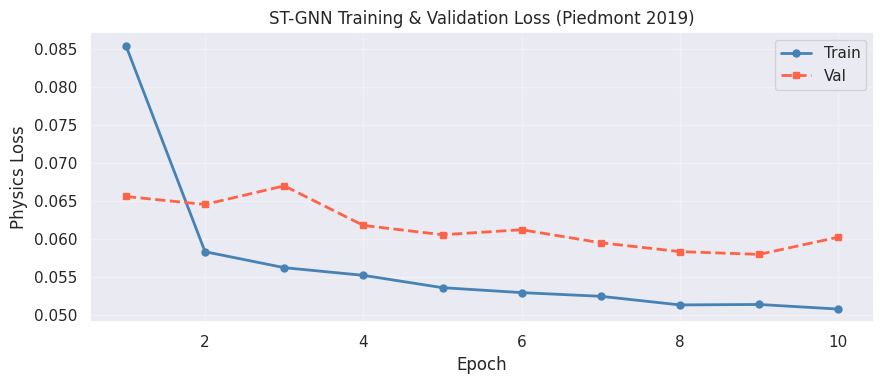

=== LOSS CURVE ===
  Epoch  1: train=0.0854  val=0.0655
  Epoch  2: train=0.0583  val=0.0645  (+31.8%)
  Epoch  3: train=0.0562  val=0.0669  (+3.6%)
  Epoch  4: train=0.0552  val=0.0617  (+1.8%)
  Epoch  5: train=0.0535  val=0.0605  (+2.9%)
  Epoch  6: train=0.0529  val=0.0612  (+1.2%)
  Epoch  7: train=0.0524  val=0.0594  (+0.9%)
  Epoch  8: train=0.0513  val=0.0583  (+2.2%)
  Epoch  9: train=0.0513  val=0.0579  (-0.1%)
  Epoch 10: train=0.0507  val=0.0602  (+1.2%)
  Total drop: 40.6%
  Best val epoch: 9  val=0.0579


In [2]:
# Loss curve
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, len(loss_history) + 1)
ax.plot(epochs, loss_history, 'o-', color='steelblue', linewidth=2, markersize=5, label='Train')
if val_loss_history:
    ax.plot(range(1, len(val_loss_history) + 1), val_loss_history, 's--', color='tomato', linewidth=2, markersize=5, label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Physics Loss')
ax.set_title('ST-GNN Training & Validation Loss (Piedmont 2019)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== LOSS CURVE ===")
for i, v in enumerate(loss_history):
    drop = f"  ({(loss_history[i-1]-v)/loss_history[i-1]*100:+.1f}%)" if i > 0 else ""
    val_str = f"  val={val_loss_history[i]:.4f}" if i < len(val_loss_history) else ""
    print(f"  Epoch {i+1:>2}: train={v:.4f}{val_str}{drop}")
total_drop = (loss_history[0] - loss_history[-1]) / loss_history[0] * 100
print(f"  Total drop: {total_drop:.1f}%")
if val_loss_history:
    best_ep = val_loss_history.index(min(val_loss_history)) + 1
    print(f"  Best val epoch: {best_ep}  val={min(val_loss_history):.4f}")

In [ ]:
# Inference: collect pred vs actual
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(DEVICE)
ei = edge_index.to(DEVICE)
ew = edge_weight.to(DEVICE)
print(f'Inference on: {DEVICE}')

if 'pv_calibration' not in globals():
    pv_calibration = {'enabled': False, 'slope': 1.0, 'intercept': 0.0, 'daytime_ghi_threshold': 0.01}

daytime_ghi_threshold = float(pv_calibration.get('daytime_ghi_threshold', 0.01))
calib_enabled = bool(pv_calibration.get('enabled', False))
calib_slope = float(pv_calibration.get('slope', 1.0))
calib_intercept = float(pv_calibration.get('intercept', 0.0))

all_pred_pv, all_true_pv = [], []
all_pred_ghi, all_true_ghi = [], []
all_time_idx = []
all_plant_id = []

with torch.no_grad():
    for i, (x, y_ghi, y_pv, eta) in enumerate(loader):
        if i >= 200:
            break
        pg, pp = model(x.to(DEVICE), ei, ew)
        pp_np = pp.cpu().numpy()
        if calib_enabled:
            pp_np = calib_slope * pp_np + calib_intercept
        pp_np = np.clip(pp_np, 0.0, None)  # softplus >= 0; calibration can push small values negative
        all_pred_pv.append(pp_np)
        all_true_pv.append(y_pv.numpy())
        all_pred_ghi.append(pg.cpu().numpy())
        all_true_ghi.append(y_ghi.numpy())

        bsz, n_plants = y_pv.shape
        sample_idx = np.arange(i * loader.batch_size, i * loader.batch_size + bsz)
        target_time_idx = dataset.valid_starts[sample_idx]
        all_time_idx.append(np.repeat(target_time_idx, n_plants))
        all_plant_id.append(np.tile(np.arange(n_plants), bsz))

pred_pv  = np.concatenate(all_pred_pv).ravel()
true_pv  = np.concatenate(all_true_pv).ravel()
pred_ghi = np.concatenate(all_pred_ghi).ravel()
true_ghi = np.concatenate(all_true_ghi).ravel()
time_idx_flat = np.concatenate(all_time_idx)
plant_id_flat = np.concatenate(all_plant_id)

# Derive QS scalar at target step from the precomputed DataArray.
qs_arr_full = np.asarray(qs.values)  # (N_plants, T)
qs_flat = np.nan_to_num(qs_arr_full[plant_id_flat, time_idx_flat], nan=0.0)

day_mask   = true_ghi > daytime_ghi_threshold
pred_pv_d, true_pv_d   = pred_pv[day_mask],  true_pv[day_mask]
pred_ghi_d, true_ghi_d = pred_ghi[day_mask], true_ghi[day_mask]
qs_d = qs_flat[day_mask]
time_idx_d = time_idx_flat[day_mask]
plant_id_d = plant_id_flat[day_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (p, t, label) in zip(axes, [
    (pred_pv_d,  true_pv_d,  'PV Output (normalised)'),
    (pred_ghi_d, true_ghi_d, 'GHI [kW/m^2]'),
]):
    lim = max(np.percentile(np.abs(t), 99), np.percentile(np.abs(p), 99))
    ax.scatter(t, p, s=2, alpha=0.2, color='steelblue')
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5, label='ideal')
    corr = float(np.corrcoef(t, p)[0, 1])
    mae  = float(np.mean(np.abs(t - p)))
    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{label}\nr={corr:.3f}  MAE={mae:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('ST-GNN: Predicted vs Actual (daytime only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

def _metrics(p, t, name):
    corr  = float(np.corrcoef(t, p)[0, 1])
    mae   = float(np.mean(np.abs(t - p)))
    rmse  = float(np.sqrt(np.mean((t - p)**2)))
    bias  = float(np.mean(p - t))
    neg   = int((p < 0).sum())
    print(f"  {name}:")
    print(f"    r={corr:.3f}  MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}")
    print(f"    actual  range: [{t.min():.3f}, {t.max():.3f}]  mean={t.mean():.3f}")
    print(f"    predicted range: [{p.min():.3f}, {p.max():.3f}]  mean={p.mean():.3f}")
    print(f"    negative predictions: {neg} ({neg/len(p)*100:.1f}%)")

print(f"\n=== SCATTER METRICS (daytime, n={day_mask.sum():,}) ===")
_metrics(pred_pv_d,  true_pv_d,  "PV Output (normalised)")
_metrics(pred_ghi_d, true_ghi_d, "GHI [kW/m^2]")

def _metrics_by_qs_bin(pred, true, qs_values):
    valid = np.isfinite(pred) & np.isfinite(true) & np.isfinite(qs_values)
    pred = pred[valid]
    true = true[valid]
    qs_values = qs_values[valid]

    bins = [
        (0.0, 0.3, "low (<0.3)"),
        (0.3, 0.5, "mid-low (0.3-0.5)"),
        (0.5, 0.7, "medium (0.5-0.7)"),
        (0.7, 0.85, "high (0.7-0.85)"),
        (0.85, 1.01, "very high (>0.85)"),
    ]

    rows = []
    print(f"\n=== PV ERROR BY QS BIN (daytime, n={len(qs_values):,}) ===")
    for lo, hi, label in bins:
        mask = (qs_values >= lo) & (qs_values < hi)
        n = int(mask.sum())
        if n == 0:
            print(f"  {label:18s}: n=0")
            continue

        err = pred[mask] - true[mask]
        mae = float(np.mean(np.abs(err)))
        rmse = float(np.sqrt(np.mean(err ** 2)))
        bias = float(np.mean(err))
        q_mean = float(np.mean(qs_values[mask]))
        true_mean = float(np.mean(true[mask]))
        pred_mean = float(np.mean(pred[mask]))
        rows.append({
            "label": label,
            "n": n,
            "q_mean": q_mean,
            "mae": mae,
            "rmse": rmse,
            "bias": bias,
            "true_mean": true_mean,
            "pred_mean": pred_mean,
        })
        print(
            f"  {label:18s}: n={n:>9,}  QS_mean={q_mean:.3f}  "
            f"MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}  "
            f"actual_mean={true_mean:.3f}  pred_mean={pred_mean:.3f}"
        )

    if len(rows) >= 2:
        qs_means = np.array([r["q_mean"] for r in rows], dtype=float)
        maes = np.array([r["mae"] for r in rows], dtype=float)
        corr = float(np.corrcoef(qs_means, maes)[0, 1])
        print(f"  QS_mean vs MAE correlation across bins: {corr:+.3f} (expected negative)")

        if rows[-1]["mae"] < rows[0]["mae"]:
            print("  Interpretation: QS is aligned with predictive reliability (higher QS -> lower MAE).")
        else:
            print("  Interpretation: QS is not monotonic here; inspect bin composition and daytime mask.")

    return rows

qs_bin_rows = _metrics_by_qs_bin(pred_pv_d, true_pv_d, qs_d)


def _print_midlow_qs_diagnostics(pred, true, ghi, qs_values, plant_ids, time_indices):
    import pandas as pd

    valid = (
        np.isfinite(pred) & np.isfinite(true) & np.isfinite(ghi) &
        np.isfinite(qs_values) & np.isfinite(plant_ids) & np.isfinite(time_indices)
    )
    pred = pred[valid]
    true = true[valid]
    ghi = ghi[valid]
    qs_values = qs_values[valid]
    plant_ids = plant_ids[valid].astype(int)
    time_indices = time_indices[valid].astype(int)

    mid = (qs_values >= 0.3) & (qs_values < 0.5)
    if int(mid.sum()) == 0:
        print("\n=== MID-LOW QS DIAGNOSTICS ===")
        print("  No samples in QS range [0.3, 0.5).")
        return None

    times_pd = pd.DatetimeIndex(ds.coords['time'].values)
    mid_times = times_pd[time_indices[mid]]
    err = pred - true

    print(f"\n=== MID-LOW QS DIAGNOSTICS (0.3 <= QS < 0.5, daytime) ===")
    print(f"  n={int(mid.sum()):,} ({mid.mean()*100:.2f}% of daytime evaluated samples)")
    print(f"  MAE={np.mean(np.abs(err[mid])):.4f}  RMSE={np.sqrt(np.mean(err[mid]**2)):.4f}  bias={np.mean(err[mid]):+.4f}")
    print(f"  actual_mean={np.mean(true[mid]):.3f}  pred_mean={np.mean(pred[mid]):.3f}  ghi_mean={np.mean(ghi[mid]):.3f}  qs_mean={np.mean(qs_values[mid]):.3f}")

    # Top plants by number of mid-low samples.
    top_rows = []
    unique_plants, counts = np.unique(plant_ids[mid], return_counts=True)
    top_order = np.argsort(counts)[::-1][:20]
    qs_arr = qs.values  # (plant, time)
    daytime_full = ds['solar_irradiance_poa'].values / 1000.0 > daytime_ghi_threshold
    for p, n in zip(unique_plants[top_order], counts[top_order]):
        m = mid & (plant_ids == p)
        p_day_qs = qs_arr[p][daytime_full[p]]
        p_day_qs = p_day_qs[np.isfinite(p_day_qs)]
        top_rows.append({
            'plant': int(p),
            'n_midlow': int(n),
            'share_midlow_%': float(n / mid.sum() * 100.0),
            'plant_day_qs_mean': float(np.mean(p_day_qs)) if len(p_day_qs) else np.nan,
            'mae': float(np.mean(np.abs(err[m]))),
            'rmse': float(np.sqrt(np.mean(err[m] ** 2))),
            'bias': float(np.mean(err[m])),
            'actual_mean': float(np.mean(true[m])),
            'pred_mean': float(np.mean(pred[m])),
            'ghi_mean': float(np.mean(ghi[m])),
        })
    top_df = pd.DataFrame(top_rows)
    print("\n  Top plants contributing to mid-low bin:")
    print(top_df.to_string(index=False, formatters={
        'share_midlow_%': '{:.2f}'.format,
        'plant_day_qs_mean': '{:.3f}'.format,
        'mae': '{:.4f}'.format,
        'rmse': '{:.4f}'.format,
        'bias': '{:+.4f}'.format,
        'actual_mean': '{:.3f}'.format,
        'pred_mean': '{:.3f}'.format,
        'ghi_mean': '{:.3f}'.format,
    }))

    def _group_summary(values, labels, title):
        values = np.asarray(values)
        mid_idx = np.where(mid)[0]
        rows = []
        for lab in labels:
            if len(values) == len(mid):
                m_idx = np.where(mid & (values == lab))[0]
            elif len(values) == len(mid_idx):
                m_idx = mid_idx[values == lab]
            else:
                raise ValueError(f"{title}: values length {len(values)} is incompatible with full length {len(mid)} and mid length {len(mid_idx)}")
            if len(m_idx) == 0:
                continue
            rows.append({
                'group': lab,
                'n': int(len(m_idx)),
                'mae': float(np.mean(np.abs(err[m_idx]))),
                'bias': float(np.mean(err[m_idx])),
                'actual_mean': float(np.mean(true[m_idx])),
                'pred_mean': float(np.mean(pred[m_idx])),
                'ghi_mean': float(np.mean(ghi[m_idx])),
            })
        df = pd.DataFrame(rows)
        print(f"\n  {title}:")
        print(df.to_string(index=False, formatters={
            'mae': '{:.4f}'.format,
            'bias': '{:+.4f}'.format,
            'actual_mean': '{:.3f}'.format,
            'pred_mean': '{:.3f}'.format,
            'ghi_mean': '{:.3f}'.format,
        }))
        return df

    month_vals = np.array([f"{m:02d}" for m in mid_times.month])
    _group_summary(month_vals, sorted(np.unique(month_vals)), "Mid-low by month")

    hour_vals = np.array([f"{h:02d}" for h in mid_times.hour])
    _group_summary(hour_vals, sorted(np.unique(hour_vals)), "Mid-low by hour")

    pv_bins = np.array(['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>=0.8'], dtype=object)
    pv_idx = np.digitize(true, [0.2, 0.4, 0.6, 0.8], right=False)
    pv_labels = pv_bins[pv_idx]
    _group_summary(pv_labels, pv_bins.tolist(), "Mid-low by actual PV range")

    ghi_bins = np.array(['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>=0.8'], dtype=object)
    ghi_idx = np.digitize(ghi, [0.2, 0.4, 0.6, 0.8], right=False)
    ghi_labels = ghi_bins[ghi_idx]
    _group_summary(ghi_labels, ghi_bins.tolist(), "Mid-low by GHI range")

    # Compare QS bins at similar production levels to avoid confounding QS with near-zero production.
    qs_bins = [
        (0.0, 0.3, 'low'),
        (0.3, 0.5, 'mid-low'),
        (0.5, 0.7, 'medium'),
        (0.7, 0.85, 'high'),
    ]
    rows = []
    for pv_lab in ['0.2-0.4', '0.4-0.6', '0.6-0.8', '>=0.8']:
        pv_m = pv_labels == pv_lab
        for lo, hi, qs_lab in qs_bins:
            m = pv_m & (qs_values >= lo) & (qs_values < hi)
            if int(m.sum()) < 100:
                continue
            rows.append({
                'actual_pv_bin': pv_lab,
                'qs_bin': qs_lab,
                'n': int(m.sum()),
                'mae': float(np.mean(np.abs(err[m]))),
                'bias': float(np.mean(err[m])),
                'actual_mean': float(np.mean(true[m])),
                'pred_mean': float(np.mean(pred[m])),
            })
    strat_df = pd.DataFrame(rows)
    print("\n  QS-bin error stratified by actual PV range:")
    print(strat_df.to_string(index=False, formatters={
        'mae': '{:.4f}'.format,
        'bias': '{:+.4f}'.format,
        'actual_mean': '{:.3f}'.format,
        'pred_mean': '{:.3f}'.format,
    }))

    # Optional QS-component breakdown (m_components already computed above).
    try:
        print("\n  QS component means inside mid-low bin:")
        for name in ['m1', 'm2', 'm3', 'm4', 'm5']:
            comp = m_components[name][plant_ids[mid], time_indices[mid]]
            comp = comp[np.isfinite(comp)]
            print(f"    {name}: mean={np.mean(comp):.3f}  median={np.median(comp):.3f}  p10={np.percentile(comp, 10):.3f}")
    except Exception as exc:
        print(f"\n  QS component breakdown skipped: {exc}")

    return {
        'top_plants': top_df,
        'stratified_by_actual_pv': strat_df,
    }

midlow_qs_diagnostics = _print_midlow_qs_diagnostics(
    pred_pv_d,
    true_pv_d,
    true_ghi_d,
    qs_d,
    plant_id_d,
    time_idx_d,
)


In [ ]:
# Time series: 3 sample plants (spread across fleet)
T_SHOW = 500
sample_plant_ids = [0, 500, 1115]

if 'pv_calibration' not in globals():
    pv_calibration = {'enabled': False, 'slope': 1.0, 'intercept': 0.0, 'daytime_ghi_threshold': 0.01}

calib_enabled   = bool(pv_calibration.get('enabled', False))
calib_slope     = float(pv_calibration.get('slope', 1.0))
calib_intercept = float(pv_calibration.get('intercept', 0.0))

seq_pred_pv  = {p: [] for p in sample_plant_ids}
seq_true_pv  = {p: [] for p in sample_plant_ids}
seq_pred_ghi = {p: [] for p in sample_plant_ids}
seq_true_ghi = {p: [] for p in sample_plant_ids}

with torch.no_grad():
    for i, (x, y_ghi, y_pv, eta) in enumerate(loader):
        if i * loader.batch_size >= T_SHOW:
            break
        pg, pp = model(x.to(DEVICE), ei, ew)
        pp_np = pp.cpu().numpy()
        pg_np = pg.cpu().numpy()
        if calib_enabled:
            pp_np = calib_slope * pp_np + calib_intercept
        pp_np = np.clip(pp_np, 0.0, None)
        for p in sample_plant_ids:
            seq_pred_pv[p].append(pp_np[:, p])
            seq_true_pv[p].append(y_pv[:, p].numpy())
            seq_pred_ghi[p].append(pg_np[:, p])
            seq_true_ghi[p].append(y_ghi[:, p].numpy())

n_plants = len(sample_plant_ids)
fig, axes = plt.subplots(n_plants, 2, figsize=(18, 4 * n_plants), sharex=True)

print("=== TIME SERIES METRICS ===")
for row, p in enumerate(sample_plant_ids):
    t_pv  = np.concatenate(seq_true_pv[p])[:T_SHOW]
    p_pv  = np.concatenate(seq_pred_pv[p])[:T_SHOW]
    t_ghi = np.concatenate(seq_true_ghi[p])[:T_SHOW]
    p_ghi = np.concatenate(seq_pred_ghi[p])[:T_SHOW]
    steps = np.arange(len(t_pv))

    # PV metrics
    corr_pv   = float(np.corrcoef(t_pv, p_pv)[0, 1]) if t_pv.std() > 0 else float('nan')
    mae_pv    = float(np.mean(np.abs(t_pv - p_pv)))
    rmse_pv   = float(np.sqrt(np.mean((t_pv - p_pv) ** 2)))
    bias_pv   = float(np.mean(p_pv - t_pv))
    amp_ratio = float(p_pv.max() / t_pv.max()) if t_pv.max() > 0 else float('nan')

    # GHI metrics
    corr_ghi = float(np.corrcoef(t_ghi, p_ghi)[0, 1]) if t_ghi.std() > 0 else float('nan')
    mae_ghi  = float(np.mean(np.abs(t_ghi - p_ghi)))
    bias_ghi = float(np.mean(p_ghi - t_ghi))

    # --- PV subplot ---
    ax_pv = axes[row, 0]
    ax_pv.fill_between(steps, 0, t_ghi * 2, alpha=0.12, color='orange', label='GHI proxy')
    ax_pv.plot(steps, t_pv, color='steelblue', linewidth=1.2, label='Actual PV')
    ax_pv.plot(steps, p_pv, color='tomato',    linewidth=1.0, linestyle='--', label='Predicted PV')
    ax_pv.set_ylabel('PV output (norm.)')
    ax_pv.set_title(f'Plant {p} — PV  r={corr_pv:.3f}  MAE={mae_pv:.4f}  bias={bias_pv:+.4f}  amp={amp_ratio:.2f}')
    ax_pv.legend(loc='upper right', fontsize=8)
    ax_pv.grid(True, alpha=0.3)

    # --- GHI subplot ---
    ax_ghi = axes[row, 1]
    ax_ghi.plot(steps, t_ghi, color='darkorange', linewidth=1.2, label='Actual GHI')
    ax_ghi.plot(steps, p_ghi, color='purple',     linewidth=1.0, linestyle='--', label='Predicted GHI')
    ax_ghi.set_ylabel('GHI [kW/m²]')
    ax_ghi.set_title(f'Plant {p} — GHI  r={corr_ghi:.3f}  MAE={mae_ghi:.4f}  bias={bias_ghi:+.4f}')
    ax_ghi.legend(loc='upper right', fontsize=8)
    ax_ghi.grid(True, alpha=0.3)

    print(f"  Plant {p:>4} PV:  r={corr_pv:.3f}  MAE={mae_pv:.4f}  RMSE={rmse_pv:.4f}  bias={bias_pv:+.4f}  amp={amp_ratio:.2f}")
    print(f"  Plant {p:>4} GHI: r={corr_ghi:.3f}  MAE={mae_ghi:.4f}  bias={bias_ghi:+.4f}")

for ax in axes[-1, :]:
    ax.set_xlabel('Timestep (hours)')

plt.suptitle('ST-GNN: Time Series — PV & GHI — 3 Sample Plants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Quality Score

In [5]:
# Diagnostic: timesteps per month (verifica gap nei CSV Sentinel)
import pandas as pd
times = pd.DatetimeIndex(ds['time'].values)
monthly_counts = pd.Series(1, index=times).resample('ME').count()
print("Timesteps per month (0 = mese assente nei CSV Sentinel):")
for mo, cnt in monthly_counts.items():
    bar = '#' * (cnt // 20)
    expected = mo.days_in_month * 24
    pct = cnt / expected * 100
    print(f"  {mo.strftime('%b %Y')}: {cnt:>4}h / {expected}h ({pct:4.0f}%)  {bar}")

Timesteps per month (0 = mese assente nei CSV Sentinel):
  Mar 2019:  694h / 744h (  93%)  ##################################
  Apr 2019:  683h / 720h (  95%)  ##################################
  May 2019:  694h / 744h (  93%)  ##################################
  Jun 2019:    0h / 720h (   0%)  
  Jul 2019:  744h / 744h ( 100%)  #####################################
  Aug 2019:    0h / 744h (   0%)  
  Sep 2019:  720h / 720h ( 100%)  ####################################
  Oct 2019:  744h / 744h ( 100%)  #####################################
  Nov 2019:  720h / 720h ( 100%)  ####################################
  Dec 2019:  744h / 744h ( 100%)  #####################################


=== QUALITY SCORE REPORT ===
  Shape: 1116 plants x 5743 timesteps
  Valid QS values: 2,719,604 / 6,409,188 (42.4%)
  Daytime valid:   2,369,755 (37.0%)

  GLOBAL (all valid):
    mean=0.653  median=0.743  std=0.252
    p10=0.000  p25=0.685  p75=0.781  p90=0.802

  DAYTIME ONLY:
    mean=0.726  median=0.751  std=0.106

  PER-PLANT (daytime mean, 1 plants no daytime data):
    min=0.111  max=0.804  mean=0.719  std=0.103
    plants QS>0.7: 907  QS 0.5-0.7: 151  QS<0.5: 57  no data: 1

  MONTHLY fleet mean (daytime only):
    Mar: 0.777  #######################
    Apr: 0.753  ######################
    May: 0.732  #####################
    Jun: NaN  (no data in Sentinel CSVs)
    Jul: 0.735  ######################
    Aug: NaN  (no data in Sentinel CSVs)
    Sep: 0.715  #####################
    Oct: 0.684  ####################
    Nov: 0.703  #####################
    Dec: 0.689  ####################


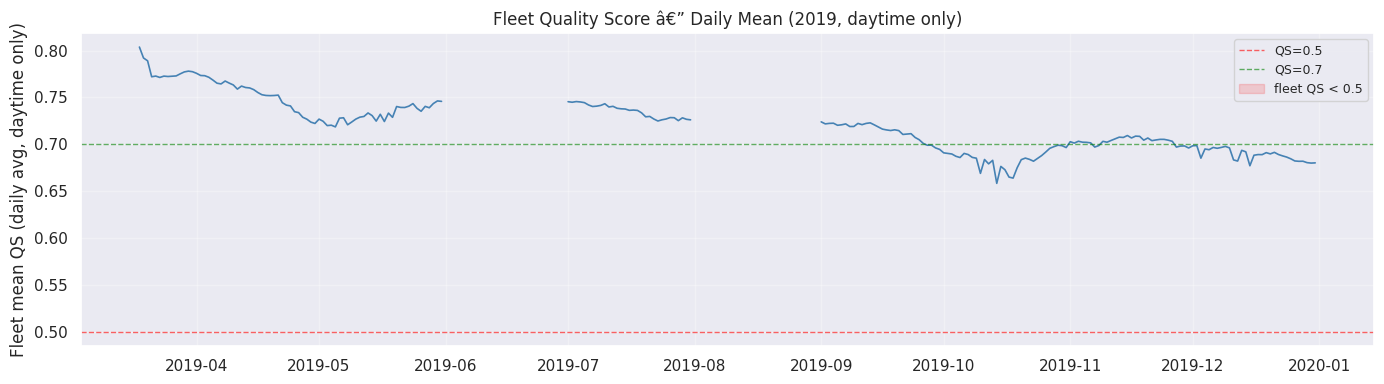

In [6]:
import pandas as pd
import warnings

qs_arr = qs.values                          # (N, T)
lats   = ds['lat'].values
lons   = ds['lon'].values
times  = pd.DatetimeIndex(ds['time'].values)
N, T   = qs_arr.shape

# Per-plant mean QS (daytime only: solar_irradiance_poa > 50 W/m^2)
poa    = ds['solar_irradiance_poa'].values  # (N, T)  W/m^2
day    = poa > 50.0
qs_day = np.where(day, qs_arr, np.nan)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    qs_plant_mean = np.nanmean(qs_day, axis=1)  # (N,) â€” NaN if plant has no daytime QS

# Fleet daily mean QS â€” daytime only (excludes spurious nighttime readings)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    qs_fleet_hourly = pd.Series(np.nanmean(qs_day, axis=0), index=times)
qs_fleet_daily  = qs_fleet_hourly.resample('1D').mean()
qs_monthly = qs_fleet_hourly.resample('ME').mean()

# --- Text report ---
qs_valid     = qs_arr[~np.isnan(qs_arr)]
qs_day_valid = qs_day[~np.isnan(qs_day)]
pm_valid     = qs_plant_mean[~np.isnan(qs_plant_mean)]
n_nan_plants = int(np.isnan(qs_plant_mean).sum())

print("=== QUALITY SCORE REPORT ===")
print(f"  Shape: {N} plants x {T} timesteps")
print(f"  Valid QS values: {len(qs_valid):,} / {qs_arr.size:,} ({len(qs_valid)/qs_arr.size*100:.1f}%)")
print(f"  Daytime valid:   {len(qs_day_valid):,} ({len(qs_day_valid)/qs_arr.size*100:.1f}%)")
print(f"\n  GLOBAL (all valid):")
print(f"    mean={np.nanmean(qs_valid):.3f}  median={np.nanmedian(qs_valid):.3f}  std={np.nanstd(qs_valid):.3f}")
print(f"    p10={np.nanpercentile(qs_valid,10):.3f}  p25={np.nanpercentile(qs_valid,25):.3f}"
      f"  p75={np.nanpercentile(qs_valid,75):.3f}  p90={np.nanpercentile(qs_valid,90):.3f}")
print(f"\n  DAYTIME ONLY:")
print(f"    mean={np.nanmean(qs_day_valid):.3f}  median={np.nanmedian(qs_day_valid):.3f}  std={np.nanstd(qs_day_valid):.3f}")
print(f"\n  PER-PLANT (daytime mean, {n_nan_plants} plants no daytime data):")
if len(pm_valid) > 0:
    print(f"    min={pm_valid.min():.3f}  max={pm_valid.max():.3f}"
          f"  mean={pm_valid.mean():.3f}  std={pm_valid.std():.3f}")
    print(f"    plants QS>0.7: {(pm_valid>0.7).sum()}"
          f"  QS 0.5-0.7: {((pm_valid>=0.5)&(pm_valid<=0.7)).sum()}"
          f"  QS<0.5: {(pm_valid<0.5).sum()}"
          f"  no data: {n_nan_plants}")
print(f"\n  MONTHLY fleet mean (daytime only):")
for mo, val in qs_monthly.items():
    if np.isnan(val):
        print(f"    {mo.strftime('%b'):>3}: NaN  (no data in Sentinel CSVs)")
    else:
        bar = '#' * int(val * 30)
        print(f"    {mo.strftime('%b'):>3}: {val:.3f}  {bar}")

# --- Fleet QS daily time series ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(qs_fleet_daily.index, qs_fleet_daily.values, linewidth=1.2, color='steelblue')
ax.axhline(0.5, color='red',    linestyle='--', alpha=0.6, linewidth=1, label='QS=0.5')
ax.axhline(0.7, color='green',  linestyle='--', alpha=0.6, linewidth=1, label='QS=0.7')
ax.fill_between(qs_fleet_daily.index, qs_fleet_daily.values, 0,
                where=qs_fleet_daily.values < 0.5, alpha=0.15, color='red', label='fleet QS < 0.5')
ax.set_ylabel('Fleet mean QS (daily avg, daytime only)')
ax.set_title('Fleet Quality Score â€” Daily Mean (2019, daytime only)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

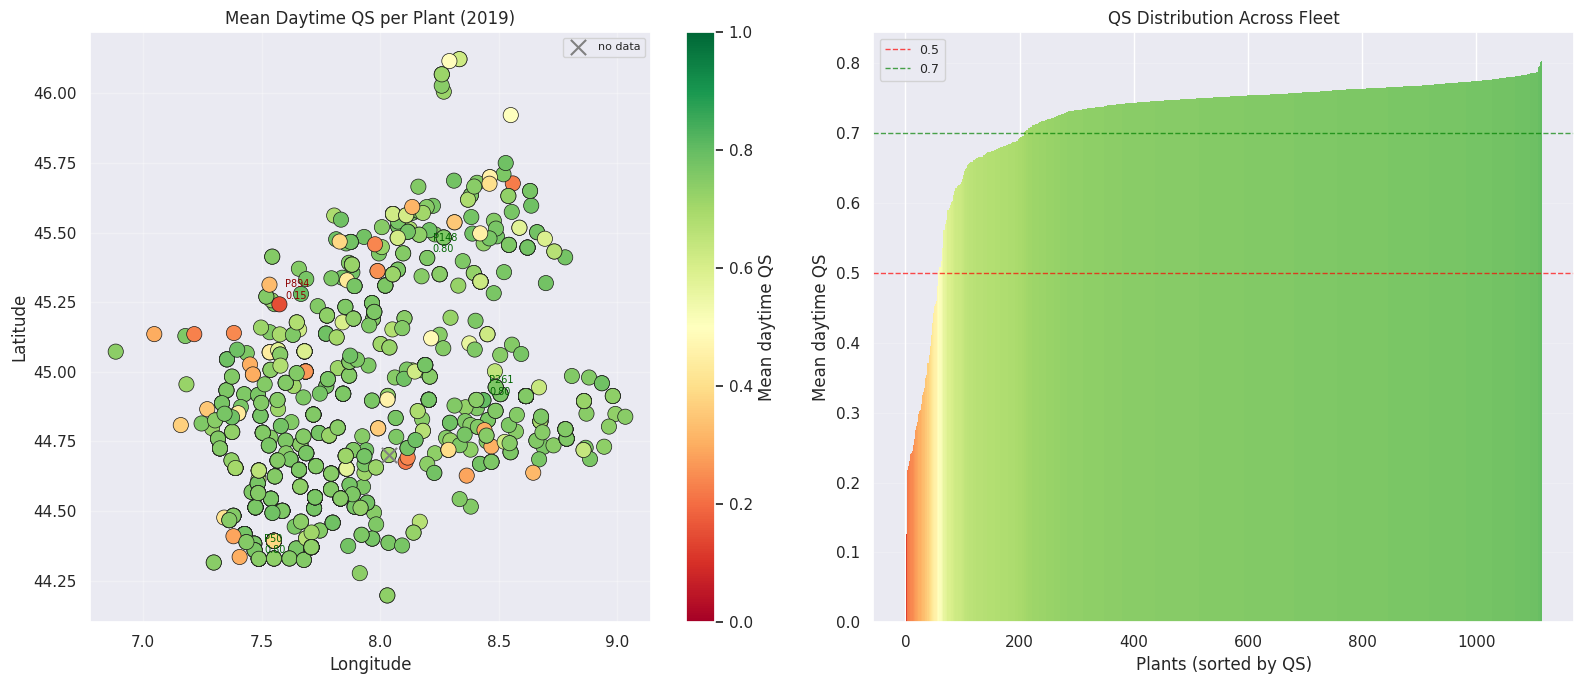

=== SPATIAL QS ===
  Top-5 plants (highest QS):
    1. Plant  148: QS=0.804  lat=45.409  lon=8.199
    2. Plant  261: QS=0.803  lat=44.898  lon=8.436
    3. Plant   50: QS=0.802  lat=44.329  lon=7.488
    4. Plant  776: QS=0.797  lat=44.545  lon=7.833
    5. Plant  638: QS=0.796  lat=44.545  lon=7.833
  Bottom-5 plants (lowest QS):
    1. Plant  946: QS=0.111  lat=nan  lon=nan
    2. Plant  846: QS=0.126  lat=nan  lon=nan
    3. Plant  894: QS=0.150  lat=45.242  lon=7.575
    4. Plant  345: QS=0.217  lat=44.677  lon=8.108
    5. Plant   47: QS=0.223  lat=45.676  lon=8.560
  Plants with no daytime data (1): [np.int64(896)]


In [7]:
# Spatial map: plants colored by mean daytime QS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: QS map (exclude NaN plants from colormap)
ax = axes[0]
valid_mask = ~np.isnan(qs_plant_mean)
sc = ax.scatter(lons[valid_mask], lats[valid_mask],
                c=qs_plant_mean[valid_mask], s=120,
                cmap='RdYlGn', vmin=0.0, vmax=1.0,
                edgecolors='k', linewidth=0.5, zorder=3)
if (~valid_mask).any():
    ax.scatter(lons[~valid_mask], lats[~valid_mask],
               s=120, c='grey', marker='x', linewidth=1.5, zorder=4, label='no data')
    ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='Mean daytime QS')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Mean Daytime QS per Plant (2019)')
ax.grid(True, alpha=0.3)

# Annotate top-3 and bottom-3 â€” exclude NaN
valid_idx = np.where(valid_mask)[0]
sorted_valid = valid_idx[np.argsort(qs_plant_mean[valid_idx])]
top3    = sorted_valid[-3:][::-1]
bottom3 = sorted_valid[:3]
for idx in top3:
    ax.annotate(f'P{idx}\n{qs_plant_mean[idx]:.2f}',
                (lons[idx], lats[idx]), fontsize=7, color='darkgreen',
                xytext=(4, 4), textcoords='offset points')
for idx in bottom3:
    ax.annotate(f'P{idx}\n{qs_plant_mean[idx]:.2f}',
                (lons[idx], lats[idx]), fontsize=7, color='darkred',
                xytext=(4, 4), textcoords='offset points')

# Right: QS distribution per plant (sorted bar)
ax2 = axes[1]
order = np.argsort(np.where(valid_mask, qs_plant_mean, -1))
colors = plt.cm.RdYlGn(np.clip(qs_plant_mean[order], 0, 1))
ax2.bar(range(N), np.where(valid_mask[order], qs_plant_mean[order], 0),
        color=colors, edgecolor='none', width=1.0)
ax2.axhline(0.5, color='red',   linestyle='--', linewidth=1, alpha=0.7, label='0.5')
ax2.axhline(0.7, color='green', linestyle='--', linewidth=1, alpha=0.7, label='0.7')
ax2.set_xlabel('Plants (sorted by QS)')
ax2.set_ylabel('Mean daytime QS')
ax2.set_title('QS Distribution Across Fleet')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

# Text: top/bottom 5 (NaN excluded)
print("=== SPATIAL QS ===")
print("  Top-5 plants (highest QS):")
for i, idx in enumerate(sorted_valid[-5:][::-1]):
    print(f"    {i+1}. Plant {idx:>4}: QS={qs_plant_mean[idx]:.3f}  lat={lats[idx]:.3f}  lon={lons[idx]:.3f}")
print("  Bottom-5 plants (lowest QS):")
for i, idx in enumerate(sorted_valid[:5]):
    print(f"    {i+1}. Plant {idx:>4}: QS={qs_plant_mean[idx]:.3f}  lat={lats[idx]:.3f}  lon={lons[idx]:.3f}")
if n_nan_plants > 0:
    nan_idx = np.where(~valid_mask)[0]
    print(f"  Plants with no daytime data ({n_nan_plants}): {list(nan_idx)}")

In [8]:
# Plant size estimates (kWp proxy) and per-plant PR
pv_scale_arr = dataset.pv_scale  # (N,) p99 ENERGIA daytime [kW]

# New pipeline uses irradiance-based reference (solar_p99).
# Keep fallback to legacy alias for old checkpoints/notebooks.
solar_p99_arr = getattr(dataset, "solar_p99", getattr(dataset, "pvgis_p99"))
eta_adj_arr = dataset.eta_adjusted  # (N,) per-plant eta proxy [dimensionless]

# kWp proxy estimate: p99(ENERGIA_day) / p99(solar_irradiance_poa_day[kW/m^2])
kWp_est = pv_scale_arr / solar_p99_arr  # (N,)

# PR proxy = eta_adjusted (data-driven ratio used in physics loss)
pr_actual = eta_adj_arr

print("=== PER-PLANT SIZE AND PERFORMANCE RATIO ===")
print(f"  {'Plant':>5}  {'kWp_est':>8}  {'PR':>6}  {'pv_scale':>9}  {'solar_p99':>9}  {'eta_adj':>8}")
print(f"  {'-'*5}  {'-'*8}  {'-'*6}  {'-'*9}  {'-'*9}  {'-'*8}")
for p in range(len(kWp_est)):
    print(f"  {p:>5}  {kWp_est[p]:>8.1f}  {pr_actual[p]:>6.3f}  {pv_scale_arr[p]:>9.1f}  {solar_p99_arr[p]:>9.3f}  {eta_adj_arr[p]:>8.3f}")

print(f"\n  FLEET SUMMARY:")
print(f"  kWp  - min={kWp_est.min():.1f}  max={kWp_est.max():.1f}  mean={kWp_est.mean():.1f}  median={np.median(kWp_est):.1f}")
print(f"  PR   - min={pr_actual.min():.3f}  max={pr_actual.max():.3f}  mean={pr_actual.mean():.3f}  std={pr_actual.std():.3f}")
print(f"  Note: kWp_est = p99(ENERGIA_day) / p99(solar_irradiance_poa_day)")
print(f"        PR proxy = eta_adjusted (irradiance-based, no pvgis_ref dependency)")


=== PER-PLANT SIZE AND PERFORMANCE RATIO ===
  Plant   kWp_est      PR   pv_scale  solar_p99   eta_adj
  -----  --------  ------  ---------  ---------  --------
      0     874.9   0.980      814.1      0.931     0.980
      1      71.0   0.961       66.0      0.930     0.961
      2     191.7   0.980      179.0      0.934     0.980
      3      71.4   0.909       66.0      0.925     0.909
      4      91.7   0.949       84.7      0.924     0.949
      5      67.6   0.980       63.0      0.932     0.980
      6     891.6   0.976      826.1      0.927     0.976
      7      81.2   0.980       76.2      0.939     0.980
      8      17.4   0.980       16.0      0.922     0.980
      9      64.6   0.921       60.0      0.929     0.921
     10      48.8   0.980       45.0      0.923     0.980
     11     883.9   0.975      827.4      0.936     0.975
     12     210.7   0.980      194.0      0.921     0.980
     13     521.8   0.980      491.9      0.943     0.980
     14    2371.6   0.828  